In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
customers=pd.read_csv('customer_master.csv')
print(customers.head())
print("customers:",customers.shape)

  customer_id       full_name  mobile_number  age  gender region date_joined  \
0  cust100000  Ryan Gallagher     7631706690   26  female  north  2024-01-28   
1  cust100001    Robert Garza      806360837   49  female   west  2025-04-16   
2  cust100002    Haley Rhodes     8124158683   68    male   west  2022-02-10   
3  cust100003    Sonya Mathis     3662585178   42    male  north  2021-02-18   
4  cust100004       Ryan Wood     9996228303   35  female  south  2023-04-17   

   is_business_user  risk_score  
0             False        0.39  
1             False        0.13  
2              True        0.14  
3             False        0.07  
4             False        0.30  
customers: (10000, 9)


In [3]:
devices=pd.read_csv('device_info.csv')
print(devices.head())
print("devices:",devices.shape)

   device_id customer_id    device_type app_version  is_rooted  \
0  dev100000  cust100000        android       2.5.4      False   
1  dev100001  cust100001  feature_phone      2.6.18      False   
2  dev100002  cust100002        android       2.5.0      False   
3  dev100003  cust100003        android      2.4.12      False   
4  dev100004  cust100004  feature_phone       4.2.0      False   

                  last_active  
0  2024-10-19 01:24:57.637823  
1  2025-07-16 01:53:08.805876  
2  2024-04-25 05:09:53.162261  
3  2021-04-24 19:10:51.551382  
4  2024-09-15 01:18:05.200875  
devices: (12000, 6)


In [4]:
upi_accounts=pd.read_csv('upi_account_details.csv')
print(upi_accounts.head())
print("upi_accounts:",upi_accounts.shape)

              upi_id customer_id bank_name        account_type  date_added  \
0  elizabeth4408@upi  cust106759       sbi             current  2022-02-22   
1     daniel5127@upi  cust104765      hdfc             savings  2022-04-02   
2      heidi2675@upi  cust102710      axis             savings  2023-12-19   
3        dr.3519@upi  cust107076      axis  credit_card_linked  2025-01-23   
4     jeremy9552@upi  cust102202       sbi             current  2025-07-18   

   status  
0  active  
1  active  
2  active  
3  active  
4  active  
upi_accounts: (12000, 6)


In [5]:

merchants=pd.read_csv('merchant_info.csv')
print(merchants.head())
print("merchants:",merchants.shape)

  merchant_id                merchant_name merchant_type region onboard_date  \
0   merch1000                 Anderson Inc       grocery  north   2022-01-14   
1   merch1001      Rojas, Newton and White        online  north   2021-08-20   
2   merch1002                   Knox-Reyes          food   west   2024-10-29   
3   merch1003  Joseph, Serrano and Gilmore       grocery  north   2023-07-22   
4   merch1004                  Brown-Jones          food  north   2024-01-02   

   risk_score  
0        0.07  
1        0.29  
2        0.20  
3        0.14  
4        0.32  
merchants: (500, 6)


In [6]:

transactions=pd.read_csv('upi_transaction_history.csv')
print(transactions.head())
print("transactions:",transactions.shape)

  transaction_id            upi_id customer_id                   timestamp  \
0    txn10000000    marisa9078@upi  cust101488  2025-06-04 21:36:19.632258   
1    txn10000001  michelle5950@upi  cust107876  2025-05-22 04:26:44.200117   
2    txn10000002   jeffery4732@upi  cust100901  2025-08-02 02:34:14.690327   
3    txn10000003      troy1833@upi  cust105890  2025-01-30 03:53:31.110447   
4    txn10000004     tammy4986@upi  cust106780  2025-07-05 21:36:52.813878   

   amount  transaction_type merchant_id counterparty_upi   status  device_id  \
0    9.88              send         NaN     user6545@upi  success  dev101488   
1   76.25           receive         NaN     user3199@upi  success  dev107876   
2   26.44  merchant_payment   merch1113     user4690@upi  success  dev100901   
3   84.43              send         NaN     user1982@upi  success  dev105890   
4   10.33           receive         NaN     user4914@upi  success  dev106780   

     device_type  channel  fraud_flag  reversal_fl

In [7]:

feedback=pd.read_csv('customer_feedback_surveys.csv')
print(feedback.head())
print("feedback:",feedback.shape)


  feedback_id customer_id date_submitted  \
0  fdbk100000  cust106029     2021-08-14   
1  fdbk100001  cust101758     2025-03-30   
2  fdbk100002  cust107269     2025-07-24   
3  fdbk100003  cust108175     2024-06-07   
4  fdbk100004  cust101420     2022-01-12   

                                       feedback_text  satisfaction_score  \
0            Weight what decision able gun shoulder.                   4   
1                  Case discuss approach leave hair.                   3   
2                     Idea as effect bed need shake.                   4   
3  Image design soldier strategy character learn ...                   4   
4  Two lose traditional approach commercial throw...                   3   

      issue_type  resolved  
0          fraud      True  
1    transaction     False  
2  app_usability     False  
3  app_usability     False  
4    transaction      True  
feedback: (4000, 7)


In [8]:

fraud_alerts=pd.read_csv('fraud_alert_history.csv')
print(fraud_alerts.head())
print("fraud_alerts:",fraud_alerts.shape)

      alert_id transaction_id        alert_type                  alert_date  \
0  alert134117    txn10034117  frequent_failure  2025-08-03 13:29:58.950559   
1  alert183925    txn10083925  frequent_failure  2024-10-09 09:41:15.203880   
2  alert163439    txn10063439      unusual_time  2025-02-23 01:23:55.939700   
3  alert164967    txn10064967  frequent_failure  2025-07-08 21:50:16.926780   
4  alert159661    txn10059661  frequent_failure  2025-08-02 22:59:36.158113   

   resolved             resolution_date  \
0     False                         NaN   
1      True  2024-10-11 02:41:15.203880   
2      True  2025-02-24 10:23:55.939700   
3      True  2025-07-09 19:50:16.926780   
4      True  2025-08-05 07:59:36.158113   

                                             remarks  
0  Strategy forward the risk necessary company re...  
1                              Art do federal short.  
2                   Age board fine participant join.  
3         Among doctor much physical interest 

In [9]:
# Check missing values in ALL 7 tables


print("1. CUSTOMERS MISSING VALUES ")
print(customers.isnull().sum())

print("\n2. DEVICES MISSING VALUES")
print(devices.isnull().sum())

print("\n3. UPI ACCOUNTS MISSING VALUES")
print(upi_accounts.isnull().sum())

print("\n4. MERCHANTS MISSING VALUES")
print(merchants.isnull().sum())

print("\n5. TRANSACTIONS MISSING VALUES")
print(transactions.isnull().sum())

print("\n6. FEEDBACK MISSING VALUES")
print(feedback.isnull().sum())

print("\n7. FRAUD ALERTS MISSING VALUES")
print(fraud_alerts.isnull().sum())


1. CUSTOMERS MISSING VALUES 
customer_id         0
full_name           0
mobile_number       0
age                 0
gender              0
region              0
date_joined         0
is_business_user    0
risk_score          0
dtype: int64

2. DEVICES MISSING VALUES
device_id      0
customer_id    0
device_type    0
app_version    0
is_rooted      0
last_active    0
dtype: int64

3. UPI ACCOUNTS MISSING VALUES
upi_id          0
customer_id     0
bank_name       0
account_type    0
date_added      0
status          0
dtype: int64

4. MERCHANTS MISSING VALUES
merchant_id      0
merchant_name    0
merchant_type    0
region           0
onboard_date     0
risk_score       0
dtype: int64

5. TRANSACTIONS MISSING VALUES
transaction_id          0
upi_id                  0
customer_id             0
timestamp               0
amount                  0
transaction_type        0
merchant_id         69851
counterparty_upi        0
status                  0
device_id               0
device_type      

In [10]:
# Check duplicates in ALL 7 tables

print("1.customers:",customers.duplicated().sum())

print("2.devices:",devices.duplicated().sum())

print("3.upi_accounts:",upi_accounts.duplicated().sum())

print("4.merchants:",merchants.duplicated().sum())

print("5.transactions:",transactions.duplicated().sum())

print("6.feedback:",feedback.duplicated().sum())

print("7.fraud_alerts:",fraud_alerts.duplicated().sum())

1.customers: 0
2.devices: 0
3.upi_accounts: 0
4.merchants: 0
5.transactions: 0
6.feedback: 0
7.fraud_alerts: 0


In [11]:

# FROM TRANSACTIONS TABLE

transactions.head(5)



,transaction_id,upi_id,customer_id,timestamp,amount,transaction_type,merchant_id,counterparty_upi,status,device_id,device_type,channel,fraud_flag,reversal_flag,failure_reason
0,txn10000000,marisa9078@upi,cust101488,2025-06-04 21:36:19.632258,9.88,send,NaN,user6545@upi,success,dev101488,feature_phone,app,False,False,NaN
1,txn10000001,michelle5950@upi,cust107876,2025-05-22 04:26:44.200117,76.25,receive,NaN,user3199@upi,success,dev107876,ios,app,False,False,NaN
2,txn10000002,jeffery4732@upi,cust100901,2025-08-02 02:34:14.690327,26.44,merchant_payment,merch1113,user4690@upi,success,dev100901,android,intent,False,False,NaN
3,txn10000003,troy1833@upi,cust105890,2025-01-30 03:53:31.110447,84.43,send,NaN,user1982@upi,success,dev105890,tablet,qr_code,False,False,NaN
4,txn10000004,tammy4986@upi,cust106780,2025-07-05 21:36:52.813878,10.33,receive,NaN,user4914@upi,success,dev106780,tablet,qr_code,False,False,NaN


In [12]:
transactions['status'].value_counts()

,count
status,
success,92140
failed,5871
pending,1989


In [13]:
len(transactions)

100000

In [14]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  object 
 1   upi_id            100000 non-null  object 
 2   customer_id       100000 non-null  object 
 3   timestamp         100000 non-null  object 
 4   amount            100000 non-null  float64
 5   transaction_type  100000 non-null  object 
 6   merchant_id       30149 non-null   object 
 7   counterparty_upi  100000 non-null  object 
 8   status            100000 non-null  object 
 9   device_id         100000 non-null  object 
 10  device_type       100000 non-null  object 
 11  channel           100000 non-null  object 
 12  fraud_flag        100000 non-null  bool   
 13  reversal_flag     100000 non-null  bool   
 14  failure_reason    5871 non-null    object 
dtypes: bool(2), float64(1), object(12)
memory usage: 10.1+ MB


In [15]:
success  = (transactions['status'] == 'success').sum()
failed   = (transactions['status'] == 'failed').sum()
pending  = (transactions['status'] == 'pending').sum()
fraud    = transactions['fraud_flag'].sum()
reversal = transactions['reversal_flag'].sum()
total    = len(transactions)
print(f"Success : {success:,}")
print(f"Failed  : {failed:,}")
print(f"Pending : {pending:,}")
print(f"Fraud   : {fraud:,}")
print(f"Reversal: {reversal:,}")
print(f"Total   : {total:,}")


Success : 92,140
Failed  : 5,871
Pending : 1,989
Fraud   : 2,000
Reversal: 1,451
Total   : 100,000


In [16]:
#KPIs

#from transactions table
success  = (transactions['status'] == 'success').sum()
failed   = (transactions['status'] == 'failed').sum()
pending  = (transactions['status'] == 'pending').sum()
fraud    = transactions['fraud_flag'].sum()
reversal = transactions['reversal_flag'].sum()
total    = len(transactions)

print('From transactions table')
print(f"Total Transactions  : {len(transactions):,}")
print(f"Success Rate        : {success/total*100:.2f}%  ({success:,} transactions)")
print(f"Failure Rate        : {failed/total*100:.2f}%   ({failed:,} transactions)")
print(f"Pending Rate        : {pending/total*100:.2f}%   ({pending:,} transactions)")
print(f"Fraud Rate          : {fraud/total*100:.2f}%   ({fraud:,} transactions)")
print(f"Reversal Rate       : {reversal/total*100:.2f}%   ({reversal:,} transactions)")
print(f"Avg Transaction Amt : Rs {transactions['amount'].mean():.2f}")
print(f"Max Transaction Amt : Rs {transactions['amount'].max():.2f}")
print(f"Min Transaction Amt : Rs {transactions['amount'].min():.2f}")


#from customers table
print("\nFrom customers table")
print(f"Total Customers     : {len(customers):,}")
print(f"Average Customer Age: {customers['age'].mean():.1f} years")
print(f"Avg Customer Risk   : {customers['risk_score'].mean():.2f}")
print(f"Business Users      : {customers['is_business_user'].sum():,}")


#from devices table
print('\nFrom devices table')
print(f"Total Devices       : {len(devices):,}")
print(f"Rooted Devices      : {devices['is_rooted'].sum():,}")

#from upi_accounts table
print("\nFrom upi_accounts table")
print(f"Total UPI Accounts : {len(upi_accounts):,}")
print('UPI Account Status Value Counts:')
print(upi_accounts['status'].value_counts())

print(f"\nNumber of Active Accounts: {(upi_accounts['status'] == 'active').sum():,}")
print(f"Number of Blocked Accounts: {(upi_accounts['status'] == 'blocked').sum():,}")

#from merchants table
print("\nFrom merchants table")
print(f"Total Merchants     : {len(merchants):,}")
print(f"Avg Merchant Risk   : {merchants['risk_score'].mean():.2f}")
threshold = merchants['risk_score'].quantile(0.75)
print(f"Threshold value     : {threshold:.2f}")                                  #high risk merchant
high_risk = merchants[merchants['risk_score'] > threshold]
print(f"High risk merchants : {len(high_risk)}")



From transactions table
Total Transactions  : 100,000
Success Rate        : 92.14%  (92,140 transactions)
Failure Rate        : 5.87%   (5,871 transactions)
Pending Rate        : 1.99%   (1,989 transactions)
Fraud Rate          : 2.00%   (2,000 transactions)
Reversal Rate       : 1.45%   (1,451 transactions)
Avg Transaction Amt : Rs 42.42
Max Transaction Amt : Rs 830.46
Min Transaction Amt : Rs 1.62

From customers table
Total Customers     : 10,000
Average Customer Age: 44.1 years
Avg Customer Risk   : 0.20
Business Users      : 1,012

From devices table
Total Devices       : 12,000
Rooted Devices      : 370

From upi_accounts table
Total UPI Accounts : 12,000
UPI Account Status Value Counts:
status
active       11148
suspended      468
blocked        384
Name: count, dtype: int64

Number of Active Accounts: 11,148
Number of Blocked Accounts: 384

From merchants table
Total Merchants     : 500
Avg Merchant Risk   : 0.18
Threshold value     : 0.26
High risk merchants : 118


In [17]:

#from feedback table

print(f"Total Feedback      : {len(feedback):,}")
print(f"Avg Satisfaction    : {feedback['satisfaction_score'].mean():.2f}/5")
print("\nCustomers Complaining About-")
issue_counts = feedback['issue_type'].value_counts()
print(issue_counts)
print("\nIssue Resolution Status-")
resolved_counts = feedback['resolved'].value_counts()
print(resolved_counts)


Total Feedback      : 4,000
Avg Satisfaction    : 3.61/5

Customers Complaining About-
issue_type
transaction      2025
app_usability     796
fraud             596
other             583
Name: count, dtype: int64

Issue Resolution Status-
resolved
True     3505
False     495
Name: count, dtype: int64


In [18]:
#from Fraud alerts table
print("\nFrom Fraud Alerts Table-")
print(f"Total Fraud Alerts  : {len(fraud_alerts):,}")
print(f"Resolved Alerts     : {fraud_alerts['resolved'].sum():,}")
print(f"Unresolved Alerts   : {(fraud_alerts['resolved']==False).sum():,}")


From Fraud Alerts Table-
Total Fraud Alerts  : 2,000
Resolved Alerts     : 1,752
Unresolved Alerts   : 248


In [19]:
#2.value_counts.................................................................................................

#transactions table- transaction_type, channel, device_type, status
print("\nTransaction Types:")
print(transactions['transaction_type'].value_counts())
print("\nChannels Used:")
print(transactions['channel'].value_counts())
print("\nDevice Types in Transactions:")
print(transactions['device_type'].value_counts())
print("\nTransaction Status:")
print(transactions['status'].value_counts())


Transaction Types:
transaction_type
send                35032
receive             34819
merchant_payment    25097
bill_pay             5052
Name: count, dtype: int64

Channels Used:
channel
app        33365
intent     33356
qr_code    33279
Name: count, dtype: int64

Device Types in Transactions:
device_type
feature_phone    25596
android          25145
ios              24783
tablet           24476
Name: count, dtype: int64

Transaction Status:
status
success    92140
failed      5871
pending     1989
Name: count, dtype: int64


In [20]:
#UPI accounts- account_type column
print("Account Types:")
print(upi_accounts['account_type'].value_counts())
print("\nAccount Status:")
print(upi_accounts['status'].value_counts())


Account Types:
account_type
current               4031
savings               4027
credit_card_linked    3942
Name: count, dtype: int64

Account Status:
status
active       11148
suspended      468
blocked        384
Name: count, dtype: int64


In [21]:
#Merchant table-merchant types
print("Merchant Types:")
print(merchants['merchant_type'].value_counts())

Merchant Types:
merchant_type
apparel        98
electronics    91
online         86
food           80
grocery        75
transport      70
Name: count, dtype: int64


In [22]:
#Fraud analysis —using transactions table only..........................

# transactions table
#Total number of fraud cases per device
total_fraud = transactions.groupby('device_type')['fraud_flag'].sum()
print("Total number of fraud cases per device:")
print(total_fraud)
#Total number of transactions per device type
total_transactions = transactions.groupby('device_type')['fraud_flag'].count()
print("\nTotal number of transactions per device:")
print(total_transactions)

fraud_rate_by_division = (total_fraud / total_transactions) * 100
print("\nFraud Rate by Device Type (%):")
print(fraud_rate_by_division.round(2))


Total number of fraud cases per device:
device_type
android          501
feature_phone    551
ios              460
tablet           488
Name: fraud_flag, dtype: int64

Total number of transactions per device:
device_type
android          25145
feature_phone    25596
ios              24783
tablet           24476
Name: fraud_flag, dtype: int64

Fraud Rate by Device Type (%):
device_type
android          1.99
feature_phone    2.15
ios              1.86
tablet           1.99
Name: fraud_flag, dtype: float64


In [23]:
#1.Total number of fraud cases per channel

print("\nFraud Rate by Channel(%):")
fraud_channel = transactions.groupby('channel')['fraud_flag'].mean() * 100
print(fraud_channel.round(2))

print("\nFraud Rate by Transaction Type(%):")
fraud_type = transactions.groupby('transaction_type')['fraud_flag'].mean() * 100
print(fraud_type.round(2))



Fraud Rate by Channel(%):
channel
app        2.02
intent     1.89
qr_code    2.10
Name: fraud_flag, dtype: float64

Fraud Rate by Transaction Type(%):
transaction_type
bill_pay            2.04
merchant_payment    2.06
receive             1.97
send                1.98
Name: fraud_flag, dtype: float64


In [24]:

#fraud by region(transactions + customers)
# merge transactions with customers

txn_with_region = pd.merge(transactions, customers, on='customer_id')
#pd.merge(transactions,customers[['customer_id', 'region', 'age']],on='customer_id',how='left')
txn_with_region.head(2)

,transaction_id,upi_id,customer_id,timestamp,amount,transaction_type,merchant_id,counterparty_upi,status,device_id,...,reversal_flag,failure_reason,full_name,mobile_number,age,gender,region,date_joined,is_business_user,risk_score
0,txn10000000,marisa9078@upi,cust101488,2025-06-04 21:36:19.632258,9.88,send,NaN,user6545@upi,success,dev101488,...,False,NaN,Marisa Meza,4477827365,52,female,east,2024-03-25,False,0.32
1,txn10000001,michelle5950@upi,cust107876,2025-05-22 04:26:44.200117,76.25,receive,NaN,user3199@upi,success,dev107876,...,False,NaN,Michelle Castillo,7122462999,45,male,central,2024-01-09,False,0.00


In [25]:
print("Total Transactions by Region:")
print(txn_with_region.groupby('region')['transaction_id'].count())

print("\nAvg Transaction Amount by Region:")
print(txn_with_region.groupby('region')['amount'].mean().round(2))

print("\nFraud Rate by Region (%):")
fraud_region = txn_with_region.groupby('region')['fraud_flag'].mean() * 100
print(fraud_region.round(2))

Total Transactions by Region:
region
central    19677
east       20078
north      20787
south      19372
west       20086
Name: transaction_id, dtype: int64

Avg Transaction Amount by Region:
region
central    42.49
east       42.53
north      42.21
south      42.54
west       42.33
Name: amount, dtype: float64

Fraud Rate by Region (%):
region
central    1.94
east       2.00
north      1.94
south      2.03
west       2.09
Name: fraud_flag, dtype: float64


In [26]:

#failure analysis- transactions table

failed_txns = transactions[transactions['status'] == 'failed']
print(f"Total Failed Transactions: {len(failed_txns):,}")

print("\nFailure Reasons:")
print(failed_txns['failure_reason'].value_counts())

print("\nFailures by Device Type:")
print(failed_txns['device_type'].value_counts())   #device failures

print("\nFailures by Transaction Type:")
print(failed_txns['transaction_type'].value_counts())    #transaction type

print("\nFailures by Channel:")
print(failed_txns['channel'].value_counts())  #channel-failures



Total Failed Transactions: 5,871

Failure Reasons:
failure_reason
incorrect_pin      1511
network_error      1486
account_blocked    1455
bank_down          1419
Name: count, dtype: int64

Failures by Device Type:
device_type
android          1525
feature_phone    1486
ios              1461
tablet           1399
Name: count, dtype: int64

Failures by Transaction Type:
transaction_type
receive             2132
send                2016
merchant_payment    1423
bill_pay             300
Name: count, dtype: int64

Failures by Channel:
channel
app        2002
intent     1968
qr_code    1901
Name: count, dtype: int64


In [27]:

status_counts = transactions['status'].value_counts()
print(status_counts)



status
success    92140
failed      5871
pending     1989
Name: count, dtype: int64


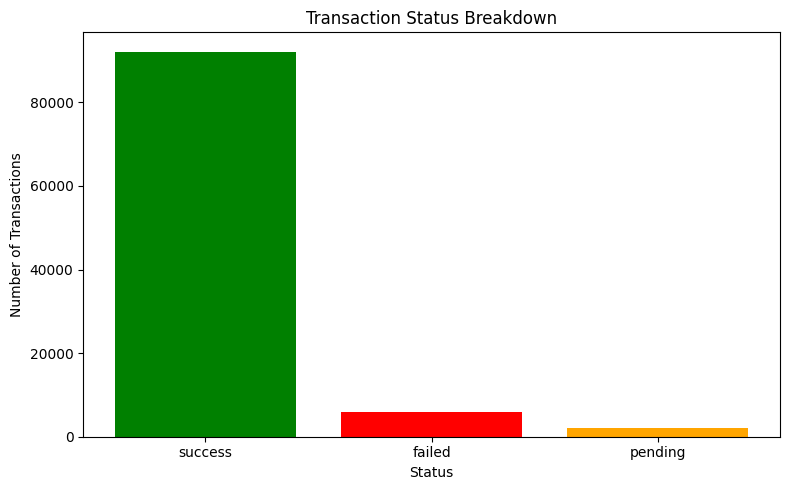

In [28]:
#bar chart for transaction status
plt.figure(figsize=(8,5))
plt.bar(status_counts.index,status_counts.values,color=['green','red','orange'])
plt.title('Transaction Status Breakdown')
plt.ylabel('Number of Transactions')
plt.xlabel('Status')
plt.tight_layout()
plt.savefig('payment_status_distribution.png')

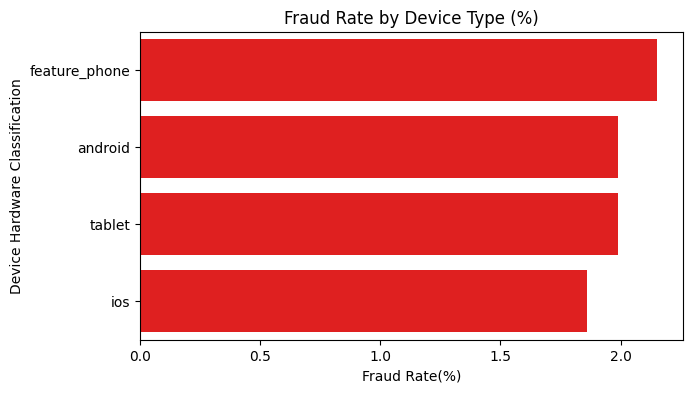

In [29]:
fraud_device = (transactions.groupby('device_type')['fraud_flag'].mean() * 100).round(2)

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_device.sort_values(ascending=False).values,y=fraud_device.sort_values(ascending=False).index,color='red')
plt.title('Fraud Rate by Device Type (%)')
plt.xlabel('Fraud Rate(%)')
plt.ylabel('Device Hardware Classification')
plt.savefig('hardware_fraud_rate_analysis.png')
plt.show()

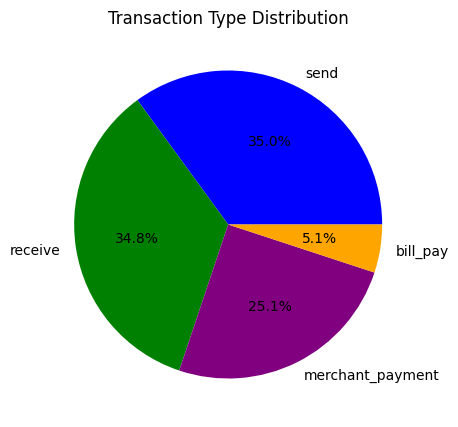

In [30]:
#Transaction types - from transactions table

type_counts = transactions['transaction_type'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['blue', 'green', 'purple', 'orange']
)
plt.title('Transaction Type Distribution')
plt.savefig('payment_type_distribution.png')
plt.show()

/tmp/ipykernel_2607/2069828613.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sat_counts.index,y=sat_counts.values,palette=['red', 'orange','purple', 'green', 'blue'])


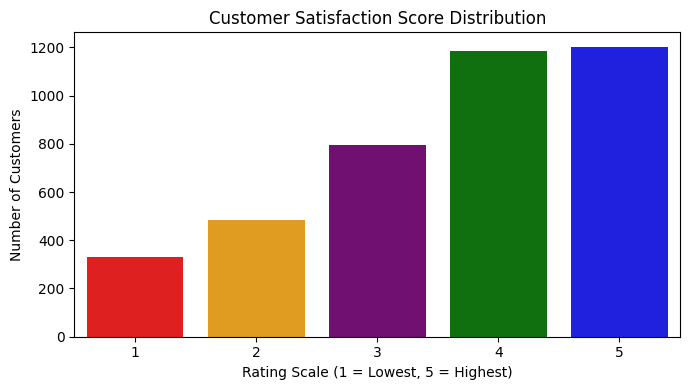

In [31]:
sat_counts = feedback['satisfaction_score'].value_counts().sort_index()
plt.figure(figsize=(7, 4))
sns.barplot(x=sat_counts.index,y=sat_counts.values,palette=['red', 'orange','purple', 'green', 'blue'])
plt.title('Customer Satisfaction Score Distribution')
plt.xlabel('Rating Scale (1 = Lowest, 5 = Highest)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('customer_satisfaction_analysis.png')
plt.show()

In [32]:
from statsmodels.stats.proportion import proportions_ztest

#Hypothesis test
#fraud_flag is in transactions table              Rooted fraud rate ≤ Non-rooted fraud rate-=H(null)
                                                  #Rooted fraud rate > Non-rooted= H(alternative)
#merge--transactions + devices

txn_dev = pd.merge(transactions, devices[['device_id', 'is_rooted']], on='device_id')
rooted_txn=txn_dev[txn_dev['is_rooted'] == True]['fraud_flag'].astype(int)
non_rooted_txn=txn_dev[txn_dev['is_rooted'] == False]['fraud_flag'].astype(int)        #Z-test, one-tailed

n1, n2 = len(rooted_txn), len(non_rooted_txn)
f1, f2 = rooted_txn.sum(), non_rooted_txn.sum()      #n-sample size and f-fraud events
z_stat, p_value = proportions_ztest([f1, f2], [n1, n2], alternative='larger')
z_critical = stats.norm.ppf(0.95)
print(f"Rooted Fraud Rate    : {f1/n1*100:.2f}%  ({f1} out of {n1})")
print(f"Non-Rooted Fraud Rate: {f2/n2*100:.2f}%   ({f2} out of {n2})")
print(f"Z-Statistic          : {z_stat:.2f}")
print(f"Z-Critical           : {z_critical:.2f}")
print(f"P-Value              : {p_value:.6f}")
alpha = 0.05
if p_value < alpha:
    print("REJECT H0 - Rooted devices have significantly higher fraud rate")
else:
    print("ACCEPT H0 - No significant difference found")

Rooted Fraud Rate    : 20.69%  (656 out of 3171)
Non-Rooted Fraud Rate: 1.39%   (1344 out of 96829)
Z-Statistic          : 76.39
Z-Critical           : 1.64
P-Value              : 0.000000
REJECT H0 - Rooted devices have significantly higher fraud rate


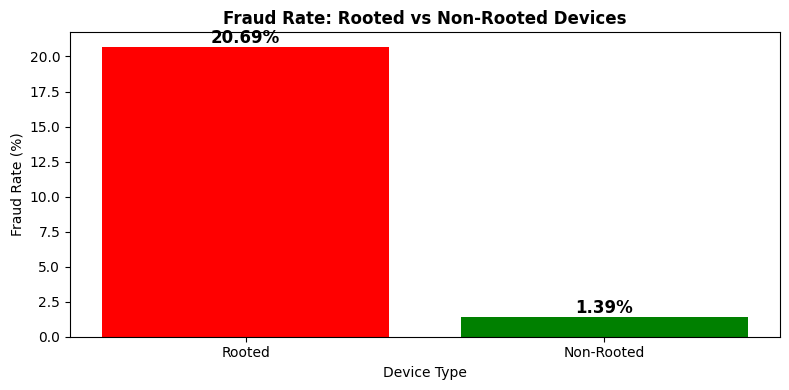

Rooted devices are 15x more likely to have fraud than non-rooted devices.


In [33]:
# rooted vs non-rooted fraud rate
labels = ['Rooted', 'Non-Rooted']
rates  = [round(f1/n1*100, 2), round(f2/n2*100, 2)]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, rates, color=['red', 'green'])
plt.title('Fraud Rate: Rooted vs Non-Rooted Devices', fontweight='bold')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate (%)')

# add label on top of each bar
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('rooted_vs_nonrooted_fraud.png', dpi=150)
plt.show()
print("Rooted devices are 15x more likely to have fraud than non-rooted devices.")

In [34]:
#Anomaly Detection-Amount-based
Q1 = transactions['amount'].quantile(0.25)
Q3 = transactions['amount'].quantile(0.75)
IQR = Q3 - Q1
amount_anomalies = transactions[transactions['amount'] > Q3 + 1.5 * IQR]
print(f"Amount-based anomalies: {len(amount_anomalies)} transactions")

# Anomaly Detection-Device-based (rooted device with high-value txn)
txn_dev['is_high_value'] = txn_dev['amount'] > txn_dev['amount'].quantile(0.95)
device_anomalies = txn_dev[(txn_dev['is_rooted']==True) & (txn_dev['is_high_value']==True)]
print(f"Rooted device + high-value anomalies: {len(device_anomalies)}")

upper_limit = Q3 + 1.5*IQR
print(upper_limit)

Amount-based anomalies: 5457 transactions
Rooted device + high-value anomalies: 153
101.89000000000001


**Note:** This 75th percentile (Q3) threshold is used only for detecting unusually large transaction amounts. Merchant risk monitoring in the Power BI dashboard uses a separate, independently chosen business threshold (risk_score > 0.4) to keep the flagged list small and actionable for weekly manual review.

In [35]:
print("Top 10 Riskiest Merchants by Fraud Rate:")
merchant_fraud = transactions.groupby('merchant_id')['fraud_flag'].mean().sort_values(ascending=False).head(10) * 100
print(merchant_fraud.round(2))

print("\nHigh Activity Customers (Top 10 by transaction count):")
top_customers = transactions.groupby('customer_id')['transaction_id'].count().sort_values(ascending=False).head(10)
print(top_customers)

print("\nCUSTOMERS BY REGION")
print(customers['region'].value_counts())
print("\nBUSINESS vs PERSONAL USERS")
print(customers['is_business_user'].value_counts())
print(f"Total customers     : {len(customers):,}")
print(f"Business users      : {customers['is_business_user'].sum():,}")
print(f"Personal users      : {(customers['is_business_user']==False).sum():,}")

print("\nBusiness vs Non-Business User Behavior:")
txn_cust = transactions.merge(customers[['customer_id','is_business_user']], on='customer_id')
print(txn_cust.groupby('is_business_user')['amount'].mean())
print(txn_cust.groupby('is_business_user')['fraud_flag'].mean()*100)

Top 10 Riskiest Merchants by Fraud Rate:
merchant_id
merch1201    10.64
merch1305     8.70
merch1358     8.06
merch1080     7.58
merch1364     7.41
merch1203     7.14
merch1307     7.02
merch1231     7.02
merch1051     6.98
merch1219     6.85
Name: fraud_flag, dtype: float64

High Activity Customers (Top 10 by transaction count):
customer_id
cust101660    71
cust105966    59
cust102584    57
cust100835    56
cust103960    56
cust104708    55
cust106552    54
cust104396    54
cust102733    54
cust103519    53
Name: transaction_id, dtype: int64

CUSTOMERS BY REGION
region
north      2071
central    2019
west       1986
south      1971
east       1953
Name: count, dtype: int64

BUSINESS vs PERSONAL USERS
is_business_user
False    8988
True     1012
Name: count, dtype: int64
Total customers     : 10,000
Business users      : 1,012
Personal users      : 8,988

Business vs Non-Business User Behavior:
is_business_user
False    42.453061
True     42.088354
Name: amount, dtype: float64
is_busin

In [36]:
print("Top 10 Risky Merchants:")
top_risky = merchants.sort_values(by='risk_score', ascending=False).head(10)[['merchant_name', 'merchant_type', 'region', 'risk_score']]
print(top_risky)

print("\nMerchant types:")
print(merchants['merchant_type'].value_counts())


Top 10 Risky Merchants:
                         merchant_name merchant_type   region  risk_score
471                    Armstrong-Brown       apparel     east        0.50
44                         May-Schultz       apparel     east        0.50
127                       Stevens-Cole          food    south        0.50
292                             Ho PLC   electronics    south        0.49
302                       Green-Horton   electronics    north        0.48
10       Moore, Christensen and Watson       apparel  central        0.48
263  Leonard, Washington and Rodriguez        online  central        0.47
27                       Jackson Group     transport    south        0.46
436           Lambert, Moore and Young   electronics     west        0.46
228             Smith, Martin and Ward       grocery    south        0.45

Merchant types:
merchant_type
apparel        98
electronics    91
online         86
food           80
grocery        75
transport      70
Name: count, dtype: int

In [37]:
#Fraud alerts analysis
print("FRAUD ALERTS ANALYSIS (from FRAUD_ALERTS table)")
print(f"Total fraud alerts  : {len(fraud_alerts):,}")
print(f"Resolved alerts     : {fraud_alerts['resolved'].sum():,}")
print(f"Unresolved alerts   : {(fraud_alerts['resolved']==False).sum():,}")
print(f"Resolution rate     : {fraud_alerts['resolved'].mean()*100:.1f}%")

print("\nAlert types:")
print(fraud_alerts['alert_type'].value_counts())

unresolved = fraud_alerts[fraud_alerts['resolved'] == False]
print(f"\nUnresolved alert types:")
print(unresolved['alert_type'].value_counts())

# UPI accounts analysis
print("\nUPI ACCOUNT STATUS (from UPI_ACCOUNTS table)")
print(upi_accounts['status'].value_counts())
print(f"\nBlocked accounts    : {(upi_accounts['status']=='blocked').sum():,}")      # FIXED: was 'Blocked'
print(f"Suspended accounts  : {(upi_accounts['status']=='suspended').sum():,}")     # FIXED: was 'Suspended'

print("\nBank distribution:")
print(upi_accounts['bank_name'].value_counts().head(10))

FRAUD ALERTS ANALYSIS (from FRAUD_ALERTS table)
Total fraud alerts  : 2,000
Resolved alerts     : 1,752
Unresolved alerts   : 248
Resolution rate     : 87.6%

Alert types:
alert_type
unusual_time        507
frequent_failure    501
suspicious_login    498
unusual_amount      494
Name: count, dtype: int64

Unresolved alert types:
alert_type
unusual_time        65
unusual_amount      64
suspicious_login    61
frequent_failure    58
Name: count, dtype: int64

UPI ACCOUNT STATUS (from UPI_ACCOUNTS table)
status
active       11148
suspended      468
blocked        384
Name: count, dtype: int64

Blocked accounts    : 384
Suspended accounts  : 468

Bank distribution:
bank_name
sbi      2036
kotak    2010
icici    2001
pnb      1992
hdfc     1990
axis     1971
Name: count, dtype: int64


In [38]:
#One-Proportion Z-test--> Overall fraud
total_transactions = len(transactions)
total_fraud_cases= int(transactions['fraud_flag'].sum())
baseline = 0.01      # 1% industry standard
z_stat,p_value = proportions_ztest(total_fraud_cases, total_transactions, value=baseline, alternative="larger")
z_critical = stats.norm.ppf(0.95)               # one-tailed, alpha=0.05
print(f"Observed Fraud Rate : {total_fraud_cases/total_transactions*100:.2f}%  ({total_fraud_cases} out of {total_transactions:,})")
print(f"Baseline (H0)       : {baseline*100}%  (industry standard)")
print(f"Z-Statistic         : {z_stat:.2f}")
print(f"Z-Critical          : {z_critical:.2f}")
print(f"P-Value             : {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("REJECT H0 - Platform fraud rate is significantly above 1% baseline")
    print("This means: Our 2% fraud rate is NOT normal. Immediate action required.")
else:
    print("ACCEPT H0 - Fraud rate is within acceptable range")

Observed Fraud Rate : 2.00%  (2000 out of 100,000)
Baseline (H0)       : 1.0%  (industry standard)
Z-Statistic         : 22.59
Z-Critical          : 1.64
P-Value             : 0.000000
REJECT H0 - Platform fraud rate is significantly above 1% baseline
This means: Our 2% fraud rate is NOT normal. Immediate action required.


In [39]:
#Chi-square tests
txn_region = pd.merge(transactions, customers[['customer_id', 'region']], on='customer_id', how='left')   #transactions + customers
#fraud vs region
ct_region = pd.crosstab(txn_region['region'], txn_region['fraud_flag'])
print("CHI-SQUARE: Fraud Flag vs Region")
contingency_table_region = pd.crosstab(
    txn_region["region"], txn_region["fraud_flag"]
)
print("Contingency Table:")
print(contingency_table_region)

(
    chi2_statistic_region,
    p_value_region,
    degrees_of_freedom_region,
    expected_frequencies_region,
) = stats.chi2_contingency(contingency_table_region)
print(f"\nChi2 Statistic : {chi2_statistic_region:.4f}")
print(f"P-Value        : {p_value_region:.6f}")
print(f"Degrees of Freedom: {degrees_of_freedom_region}")
if p_value_region < 0.05:
    print("REJECT H0 - Fraud IS associated with region")
else:
    print(
        "FAIL TO REJECT H0 - Fraud is NOT associated with region (p=0.82, no pattern)"
    )


#fraud vs channel
print("\nCHI-SQUARE: Fraud Flag vs Channel")
contingency_table_channel = pd.crosstab(
    transactions["channel"], transactions["fraud_flag"]
)
print("Contingency Table:")
print(contingency_table_channel)

(
    chi2_statistic_channel,
    p_value_channel,
    degrees_of_freedom_channel,
    expected_frequencies_channel,
) = stats.chi2_contingency(contingency_table_channel)
print(f"\nChi2 Statistic : {chi2_statistic_channel:.4f}")
print(f"P-Value        : {p_value_channel:.6f}")
print(f"Degrees of Freedom: {degrees_of_freedom_channel}")
if p_value_channel < 0.05:
    print("REJECT H0 - Fraud IS associated with channel")
else:
    print(
        "FAIL TO REJECT H0 - Fraud is NOT associated with channel (p=0.14, no pattern)"
    )

CHI-SQUARE: Fraud Flag vs Region
Contingency Table:
fraud_flag  False  True 
region                  
central     19295    382
east        19676    402
north       20383    404
south       18979    393
west        19667    419

Chi2 Statistic : 1.5240
P-Value        : 0.822387
Degrees of Freedom: 4
FAIL TO REJECT H0 - Fraud is NOT associated with region (p=0.82, no pattern)

CHI-SQUARE: Fraud Flag vs Channel
Contingency Table:
fraud_flag  False  True 
channel                 
app         32692    673
intent      32727    629
qr_code     32581    698

Chi2 Statistic : 3.8837
P-Value        : 0.143435
Degrees of Freedom: 2
FAIL TO REJECT H0 - Fraud is NOT associated with channel (p=0.14, no pattern)


In [40]:
#One-Way ANOVA--Region-wise fraud rate
txn_region["fraud_int"] = txn_region["fraud_flag"].astype(int)

# Create one array per region
east = txn_region[txn_region["region"] == "east"]["fraud_int"].values
west = txn_region[txn_region["region"] == "west"]["fraud_int"].values
north = txn_region[txn_region["region"] == "north"]["fraud_int"].values
south = txn_region[txn_region["region"] == "south"]["fraud_int"].values
central = txn_region[txn_region["region"] == "central"]["fraud_int"].values

f_statistic, p_value = stats.f_oneway(east, west, north, south, central)

print("ONE-WAY ANOVA: Region-wise Fraud Rate")
print(f"F-Statistic : {f_statistic:.2f}")
print(f"P-Value     : {p_value:.2f}")
print()
print("Fraud rate per region:")
print(txn_region.groupby("region")["fraud_int"].mean().mul(100).round(2))

alpha = 0.05
if p_value < alpha:
    print("\nREJECT H0 - Fraud rate differs significantly across regions")
else:
    print(
        "\nFAIL TO REJECT H0 - No significant difference in fraud rate across regions (p=0.82)"
    )
    print("This means: Fraud is uniformly distributed — not a regional problem.")


ONE-WAY ANOVA: Region-wise Fraud Rate
F-Statistic : 0.38
P-Value     : 0.82

Fraud rate per region:
region
central    1.94
east       2.00
north      1.94
south      2.03
west       2.09
Name: fraud_int, dtype: float64

FAIL TO REJECT H0 - No significant difference in fraud rate across regions (p=0.82)
This means: Fraud is uniformly distributed — not a regional problem.
